#Final Report Written by AI

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import sys
sys.path.append('../')

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA as SklearnPCA

from minilearn.classifiers import LogisticRegression as MiniLR
from minilearn.classifiers import GaussianNaiveBayes as MiniNB
from minilearn.classifiers import KNearestNeighbors as MiniKNN
from minilearn.classifiers import SVM as MiniSVM
from minilearn.classifiers import DecisionTree as MiniDT
from minilearn.classifiers import KMeans as MiniKMeans
from minilearn.decomposition import PCA as MiniPCA
from minilearn.neural_network import ANN as MiniANN
from minilearn.metrics import (accuracy_score as mini_accuracy, precision_score as mini_precision, recall_score as mini_recall, f1_score as mini_f1, classification_report as mini_report)



# Speech Emotion Recognition (SER) Using the RAVDESS Dataset
## CSE 432/532 — Machine Learning Semester Project

---

## Introduction

### What is Speech Emotion Recognition?
Speech Emotion Recognition (SER) is the task of automatically identifying 
the emotional state of a speaker from their voice. This is a challenging 
problem in machine learning because emotions are complex, subjective, and 
often expressed subtly through variations in pitch, energy, rhythm, and 
spectral characteristics of speech.

SER has many real world applications including:
- Mental health monitoring and therapy assistance
- Customer service quality assessment
- Human-computer interaction
- Driver safety monitoring
- Sentiment analysis in call centers

### The RAVDESS Dataset
This project uses the Ryerson Audio-Visual Database of Emotional Speech 
and Song (RAVDESS), a validated multimodal database of emotional speech 
and song recordings. We use the audio-only portion of the dataset.

**Dataset Statistics:**
- 24 professional actors (12 male, 12 female)
- 2 vocal channels: speech and song
- 8 emotional categories: neutral, calm, happy, sad, angry, fearful, 
disgust, and surprised
- 2,452 total audio files (1,440 speech + 1,012 song)
- 16-bit, 48kHz WAV format

### Project Overview
This project builds an end-to-end SER system that:
1. Extracts meaningful audio features from raw recordings
2. Implements core ML algorithms from scratch in a custom library called MiniLearn
3. Applies and compares classical and modern classification techniques
4. Evaluates models using rigorous cross-validation and metrics
5. Explores unsupervised learning and dimensionality reduction

### MiniLearn Library
A key component of this project is MiniLearn — a custom Python ML library 
built from scratch. MiniLearn implements the following algorithms:
- **Preprocessing:** StandardScaler, train_test_split, KFold
- **Classifiers:** Logistic Regression, Gaussian Naive Bayes, KNN, SVM, Decision Tree, KMeans, ANN
- **Regression:** Linear Regression
- **Decomposition:** PCA
- **Metrics:** accuracy, precision, recall, F1 score, confusion matrix, classification report

## 2. Feature Extraction

### 2.1 Hand-Crafted Audio Features
For each audio file, the following features were extracted using the librosa 
library. Since each audio file has a different length, summary statistics 
(mean and standard deviation) were computed over frames to produce a 
fixed-length feature vector.

| Feature | Description | # Values |
|---|---|---|
| MFCCs (13 coefficients) | Compact spectral envelope representation | 26 |
| MFCC Deltas (1st order) | Rate of change of MFCCs | 26 |
| MFCC Delta-Deltas (2nd order) | Acceleration of MFCCs | 26 |
| Zero Crossing Rate | Rate of signal sign changes | 2 |
| RMS Energy | Loudness per frame | 2 |
| Spectral Centroid | Center of mass of spectrum | 2 |
| Spectral Bandwidth | Width of spectral band | 2 |
| Spectral Rolloff | Frequency of 85% energy | 2 |
| Chroma Features | 12 pitch class profile | 24 |
| **Total** | | **112** |

### 2.2 Feature Standardization
All features were standardized using z-score normalization before classification. 
To avoid data leakage, the scaler was fit on training data only and then applied 
to both training and test sets.

### 2.3 Train/Test Split
The dataset was split into 80% training (1,961 samples) and 20% test (491 samples) 
using stratified splitting to maintain class proportions.

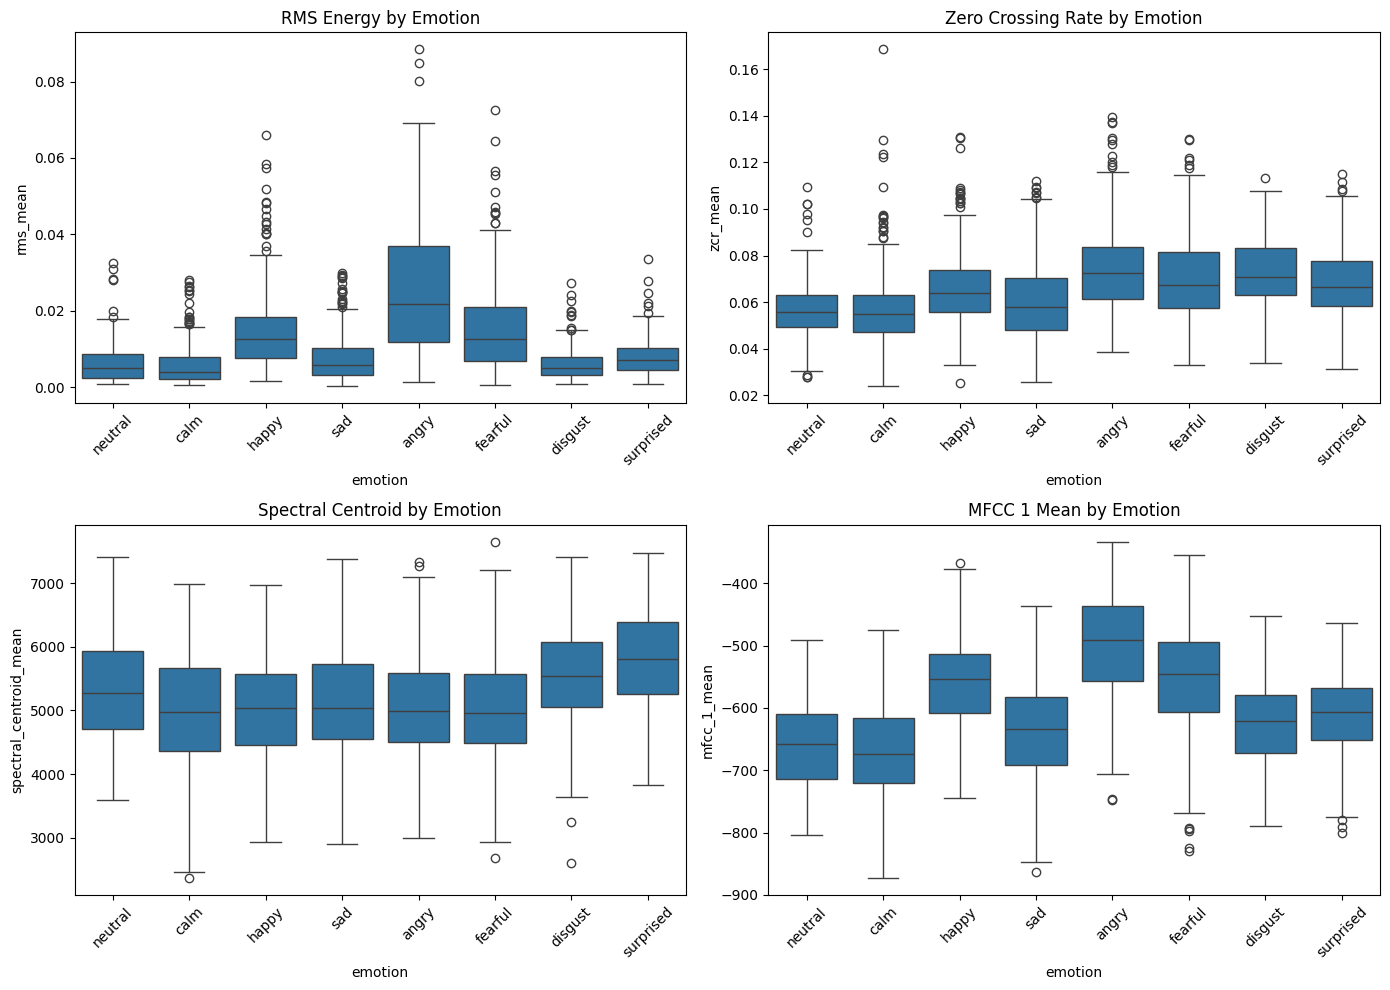

In [3]:
# Load train and test data
features_df = pd.read_csv('../data/features.csv')
features_df['emotion'] = features_df['emotion'].str.strip()

train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

feature_cols = [col for col in train_df.columns if col != 'emotion']
X_train = train_df[feature_cols].values
y_train = train_df['emotion'].str.strip().values
X_test = test_df[feature_cols].values
y_test = test_df['emotion'].str.strip().values

# Feature distributions by emotion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=features_df, x='emotion', y='rms_mean', ax=axes[0,0])
axes[0,0].set_title('RMS Energy by Emotion')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=features_df, x='emotion', y='zcr_mean', ax=axes[0,1])
axes[0,1].set_title('Zero Crossing Rate by Emotion')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=features_df, x='emotion', y='spectral_centroid_mean', ax=axes[1,0])
axes[1,0].set_title('Spectral Centroid by Emotion')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=features_df, x='emotion', y='mfcc_1_mean', ax=axes[1,1])
axes[1,1].set_title('MFCC 1 Mean by Emotion')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. Supervised Learning & Classification

### 3.1 Models Implemented
The following models were implemented from scratch in MiniLearn and compared 
against their sklearn equivalents:

| Model | MiniLearn | Sklearn | Week |
|---|---|---|---|
| Linear Regression | ✅ | ✅ | 6 |
| Logistic Regression | ✅ | ✅ | 7 |
| Gaussian Naive Bayes | ✅ | ✅ | 7 |
| K-Nearest Neighbors | ✅ | ✅ | 7 |
| Support Vector Machine | ✅ | ✅ | 8 |
| Decision Tree (CART) | ✅ | ✅ | 9 |
| Random Forest | ❌ | ✅ | 9 |
| AdaBoost | ❌ | ✅ | 9 |
| ANN | ✅ | PyTorch | 13 |

### 3.2 Model Evaluation Strategy
All models were evaluated using:
- **Stratified K-Fold Cross Validation** (k=5)
- **Metrics:** Accuracy, Precision, Recall, F1 Score, Confusion Matrix
- **MiniLearn metrics module** used to verify results against sklearn

In [4]:
# Final model comparison using cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

models = {
    'Logistic Regression': SklearnLR(max_iter=1000),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN k=5': KNeighborsClassifier(n_neighbors=5),
    'SVM RBF C=10': SVC(kernel='rbf', C=10, gamma='scale'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest Tuned': RandomForestClassifier(n_estimators=300, max_depth=None,min_samples_split=5,max_features='sqrt',random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Cross validating {name}...")
    scores = cross_val_score(model, X_all, y_all, cv=skf, scoring='accuracy')
    results[name] = {
        'mean': np.mean(scores),
        'std': np.std(scores)
    }
    print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

Cross validating Logistic Regression...
Logistic Regression: 0.6452 (+/- 0.0115)
Cross validating Gaussian Naive Bayes...
Gaussian Naive Bayes: 0.3834 (+/- 0.0174)
Cross validating KNN k=5...
KNN k=5: 0.5526 (+/- 0.0207)
Cross validating SVM RBF C=10...
SVM RBF C=10: 0.7357 (+/- 0.0160)
Cross validating Decision Tree...
Decision Tree: 0.3650 (+/- 0.0160)
Cross validating Random Forest...
Random Forest: 0.6150 (+/- 0.0205)
Cross validating Random Forest Tuned...
Random Forest Tuned: 0.6391 (+/- 0.0253)
